# Create WecOptTool Model for the Marson WEC concept

In [5]:
import logging
import numpy as np
import capytaine as cpt
import pygmsh
import gmsh
import vtk
import os
import matplotlib.pyplot as plt
import xarray as xr
from capytaine.io.legacy import export_hydrostatics

logging.basicConfig(level=logging.INFO,format="%(levelnames)s:\t%(message)s")

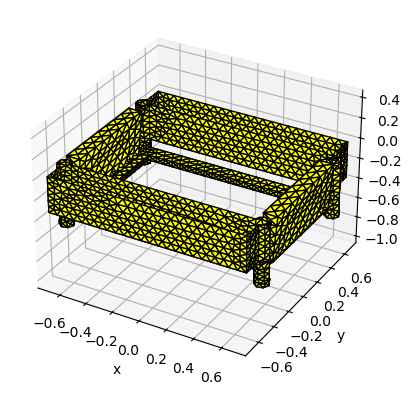

In [6]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop = 0.1

platformLength = 1.44 
outboardWidth = 0.1
platformWidth = 0.76+2*outboardWidth
platformHeight = 0.05
platformCenter = [0, 0, -0.46]
columnsRadius = 0.05
columnsDraft = 0.6
columnsXY = [platformLength/2, platformWidth/2]
cutoutWidth = 0.76
cutoutLength = 1.44-2*outboardWidth

# floats attached to side of platform
floatWidth = 0.2
floatHeight = 0.35

flapWidth = platformWidth-2*outboardWidth
flapHeight = 0.45
flap1CG = [-platformLength/2, 0, -0.36] # from water surface/origin
flap2CG = [platformLength/2, 0, -0.36] # from water surface/origin

with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformLength/2, -platformWidth/2, platformCenter[2] - platformHeight/2], [platformLength,platformWidth,platformHeight])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, platformCenter[2] - platformHeight/2], [cutoutLength,cutoutWidth,platformHeight])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    float1 = geom.add_box([-platformLength/2, -platformWidth/2-0.2, -floatHeight], [platformLength,floatWidth,floatHeight])
    float2 = geom.add_box([-platformLength/2, platformWidth/2, -floatHeight], [platformLength,floatWidth,floatHeight])
    platformCutout = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformCutout,cyl1,cyl2,cyl3,cyl4,float1,float2])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-platformLength/2 - flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [-platformLength/2 + flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [-platformLength/2 + flapThicknessTop/2, -flapWidth/2, -.01],
            [-platformLength/2 - flapThicknessTop/2, -flapWidth/2, -.01]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[platformLength/2 - flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [platformLength/2 + flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [platformLength/2 + flapThicknessTop/2, -flapWidth/2, -.01],
            [platformLength/2 - flapThicknessTop/2, -flapWidth/2, -.01]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()


# define the floating body
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=[0,0,-0.54])
platform = platform.immersed_part()
platform.rotation_center = platform.center_of_mass
platform.add_all_rigid_body_dofs()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1 = flap1.immersed_part()
flap1.rotation_center = flap1.center_of_mass
flap1.add_all_rigid_body_dofs()
flap1.hydrostatic_stiffness = flap1.compute_hydrostatic_stiffness(rho=1025)

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2 = flap2.immersed_part()
flap2.rotation_center = flap2.center_of_mass
flap2.add_all_rigid_body_dofs()

all_bodies = platform + flap1 + flap2

#all_bodies.show()
all_bodies.show_matplotlib()

#### WEC geometry mesh
Now we will create a surface mesh for the WEC hull and store it using the `FloatingBody` object from Capytaine.

In [7]:
platform.inertia_matrix = platform.compute_rigid_body_inertia()
platform.hydrostatic_stiffness = platform.compute_hydrostatic_stiffness()
flap1.inertia_matrix = flap1.compute_rigid_body_inertia()
flap1.hydrostatic_stiffness = flap1.compute_hydrostatic_stiffness()
flap2.inertia_matrix = flap2.compute_rigid_body_inertia()
flap2.hydrostatic_stiffness = flap2.compute_hydrostatic_stiffness()

In [ ]:
ncFName = 'foswec.nc'

path,tmp = os.path.split(os.getcwd() + os.path.sep + ncFName)
path += os.path.sep

freqs = np.linspace(1/8, 10*1/8, 10)

# set frequencies
wCapy =  2*np.pi*freqs                  # wave frequencies
headings = np.linspace(0,np.pi/2,1)  
depth = np.inf
density = 1025.0

# call Capytaine solver
print(f'\n-------------------------------\n'
    f'Calling Capytaine BEM solver...\n'
    f'-------------------------------\n'
    f'mesh = {all_bodies.name}\n'
    f'w range = {wCapy[0]:.3f} - {wCapy[-1]:.3f} rad/s\n'
    f'dw = {(wCapy[1]-wCapy[0]):.3f} rad/s\n'
    f'no of headings = {len(headings)}\n'
    f'no of radiation & diffraction problems = {len(wCapy)*(len(headings) + len(all_bodies.dofs))}\n'
    f'-------------------------------\n')

problems = xr.Dataset(coords={
    'omega': wCapy,
    'wave_direction': headings,
    'radiating_dof': list(all_bodies.dofs),
    'water_depth': [depth],
    'rho': [density],
    })

solver = cpt.BEMSolver()
dataset = solver.fill_dataset(problems, all_bodies.immersed_part(), n_jobs=2)


cpt.export_dataset('foswec.nc', dataset)
export_hydrostatics('hs/', [platform, flap1, flap2])



-------------------------------
Calling Capytaine BEM solver...
-------------------------------
mesh = platform+flap1+flap2
w range = 0.785 - 7.854 rad/s
dw = 0.785 rad/s
no of headings = 1
no of radiation & diffraction problems = 190
-------------------------------



Output()

FileNotFoundError: [WinError 3] The system cannot find the path specified: ''